# New Charts

## Set Up

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import io

data_path = '/content/drive/MyDrive/CMPE206 Project Data/'

df_latency = pd.read_csv(data_path + 'high-latency-output.csv')
df_low_latency_congestion = pd.read_csv(data_path + 'high-congestion-low-latency-output.csv')
df_high_latency_congestion = pd.read_csv(data_path + 'high-congestion-high-latency-output.csv')

In [ ]:
df_latency

,Protocol,SourceAddress,DestinationAddress,SourcePort,DestinationPort,Latency,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,ThroughputKbps,MeanDelayMs,MeanJitterMs
0,TCP,10.1.1.1,10.1.2.2,49153,7,2ms,9652,9547,70,10383508,10270528,1360.18,218.603,2.933160
1,UDP,10.1.3.1,10.1.2.2,49153,9,2ms,21606,18213,3303,22729512,19160076,2537.22,240.567,1.316520
2,TCP,10.1.1.1,10.1.2.2,49153,7,50ms,8310,8173,59,8939516,8792104,1164.25,311.155,3.153360
3,UDP,10.1.3.1,10.1.2.2,49153,9,50ms,21606,19446,2063,22729512,20457192,2709.17,319.435,1.210300
4,TCP,10.1.1.1,10.1.2.2,49153,7,200ms,7104,7032,0,7641860,7564388,1001.73,610.372,1.279200
5,UDP,10.1.3.1,10.1.2.2,49153,9,200ms,21606,20323,1063,22729512,21379796,2831.21,609.441,1.027910
6,TCP,10.1.1.1,10.1.2.2,49153,7,400ms,4228,4143,0,4547284,4455824,590.05,822.631,1.829450
7,UDP,10.1.3.1,10.1.2.2,49153,9,400ms,21606,21311,0,22729512,22419172,2968.83,815.508,0.598694


In [ ]:
df_low_latency_congestion

,Protocol,SourceAddress,DestinationAddress,SourcePort,DestinationPort,Mbps,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,ThroughputKbps,MeanDelayMs,MeanJitterMs
0,TCP,10.1.1.1,10.1.2.2,49153,7,1Mbps,7203,7201,0,7748384,7746232,1025.84,10.0984,0.000836
1,UDP,10.1.3.1,10.1.2.2,49153,9,1Mbps,7202,7201,0,7576504,7575452,1003.26,8.2160,0.000000
2,TCP,10.1.1.1,10.1.2.2,49153,7,2Mbps,12872,12757,76,13848228,13724488,1817.34,161.4990,2.844600
3,UDP,10.1.3.1,10.1.2.2,49153,9,2Mbps,14404,14340,23,15153008,15085680,1997.79,152.2080,1.032790
4,TCP,10.1.1.1,10.1.2.2,49153,7,3Mbps,9652,9547,70,10383508,10270528,1360.18,218.6030,2.933160
5,UDP,10.1.3.1,10.1.2.2,49153,9,3Mbps,21606,18213,3303,22729512,19160076,2537.22,240.5670,1.316520
6,TCP,10.1.1.1,10.1.2.2,49153,7,4Mbps,9663,9602,34,10395344,10329708,1368.16,224.4090,2.960710
7,UDP,10.1.3.1,10.1.2.2,49153,9,4Mbps,28808,18166,10461,30306016,19110632,2530.64,601.5550,1.104430


In [ ]:
df_high_latency_congestion

,Protocol,SourceAddress,DestinationAddress,SourcePort,DestinationPort,Mbps,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,ThroughputKbps,MeanDelayMs,MeanJitterMs
0,TCP,10.1.1.1,10.1.2.2,49153,7,1Mbps,4212,4114,0,4530068,4424620,585.935,806.057,0.220848
1,UDP,10.1.3.1,10.1.2.2,49153,9,1Mbps,7202,7103,0,7576504,7472356,989.725,804.378,0.032944
2,TCP,10.1.1.1,10.1.2.2,49153,7,2Mbps,4246,4173,0,4566652,4488104,594.301,809.692,0.539228
3,UDP,10.1.3.1,10.1.2.2,49153,9,2Mbps,14404,14207,0,15153008,14945764,1979.310,805.912,0.187060
4,TCP,10.1.1.1,10.1.2.2,49153,7,3Mbps,4228,4143,0,4547284,4455824,590.050,822.631,1.829450
5,UDP,10.1.3.1,10.1.2.2,49153,9,3Mbps,21606,21311,0,22729512,22419172,2968.830,815.508,0.598694
6,TCP,10.1.1.1,10.1.2.2,49153,7,4Mbps,1164,1105,18,1250420,1186936,161.490,1033.040,4.487900
7,UDP,10.1.3.1,10.1.2.2,49153,9,4Mbps,28808,26478,1777,30306016,27854856,3688.660,1216.070,0.253490


In [ ]:
# Removing units on Mbps and latency

df_latency['Latency'] = df_latency['Latency'].apply(lambda x: int(x[:-2]))
df_low_latency_congestion['Mbps'] = df_low_latency_congestion['Mbps'].apply(lambda x: int(x[0]))
df_high_latency_congestion['Mbps'] = df_high_latency_congestion['Mbps'].apply(lambda x: int(x[0]))


In [ ]:
df_latency

,Protocol,SourceAddress,DestinationAddress,SourcePort,DestinationPort,Latency,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,ThroughputKbps,MeanDelayMs,MeanJitterMs
0,TCP,10.1.1.1,10.1.2.2,49153,7,2,9652,9547,70,10383508,10270528,1360.18,218.603,2.933160
1,UDP,10.1.3.1,10.1.2.2,49153,9,2,21606,18213,3303,22729512,19160076,2537.22,240.567,1.316520
2,TCP,10.1.1.1,10.1.2.2,49153,7,50,8310,8173,59,8939516,8792104,1164.25,311.155,3.153360
3,UDP,10.1.3.1,10.1.2.2,49153,9,50,21606,19446,2063,22729512,20457192,2709.17,319.435,1.210300
4,TCP,10.1.1.1,10.1.2.2,49153,7,200,7104,7032,0,7641860,7564388,1001.73,610.372,1.279200
5,UDP,10.1.3.1,10.1.2.2,49153,9,200,21606,20323,1063,22729512,21379796,2831.21,609.441,1.027910
6,TCP,10.1.1.1,10.1.2.2,49153,7,400,4228,4143,0,4547284,4455824,590.05,822.631,1.829450
7,UDP,10.1.3.1,10.1.2.2,49153,9,400,21606,21311,0,22729512,22419172,2968.83,815.508,0.598694


In [ ]:
df_low_latency_congestion

,Protocol,SourceAddress,DestinationAddress,SourcePort,DestinationPort,Mbps,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,ThroughputKbps,MeanDelayMs,MeanJitterMs
0,TCP,10.1.1.1,10.1.2.2,49153,7,1,7203,7201,0,7748384,7746232,1025.84,10.0984,0.000836
1,UDP,10.1.3.1,10.1.2.2,49153,9,1,7202,7201,0,7576504,7575452,1003.26,8.2160,0.000000
2,TCP,10.1.1.1,10.1.2.2,49153,7,2,12872,12757,76,13848228,13724488,1817.34,161.4990,2.844600
3,UDP,10.1.3.1,10.1.2.2,49153,9,2,14404,14340,23,15153008,15085680,1997.79,152.2080,1.032790
4,TCP,10.1.1.1,10.1.2.2,49153,7,3,9652,9547,70,10383508,10270528,1360.18,218.6030,2.933160
5,UDP,10.1.3.1,10.1.2.2,49153,9,3,21606,18213,3303,22729512,19160076,2537.22,240.5670,1.316520
6,TCP,10.1.1.1,10.1.2.2,49153,7,4,9663,9602,34,10395344,10329708,1368.16,224.4090,2.960710
7,UDP,10.1.3.1,10.1.2.2,49153,9,4,28808,18166,10461,30306016,19110632,2530.64,601.5550,1.104430


In [ ]:
df_high_latency_congestion

,Protocol,SourceAddress,DestinationAddress,SourcePort,DestinationPort,Mbps,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,ThroughputKbps,MeanDelayMs,MeanJitterMs
0,TCP,10.1.1.1,10.1.2.2,49153,7,1,4212,4114,0,4530068,4424620,585.935,806.057,0.220848
1,UDP,10.1.3.1,10.1.2.2,49153,9,1,7202,7103,0,7576504,7472356,989.725,804.378,0.032944
2,TCP,10.1.1.1,10.1.2.2,49153,7,2,4246,4173,0,4566652,4488104,594.301,809.692,0.539228
3,UDP,10.1.3.1,10.1.2.2,49153,9,2,14404,14207,0,15153008,14945764,1979.310,805.912,0.187060
4,TCP,10.1.1.1,10.1.2.2,49153,7,3,4228,4143,0,4547284,4455824,590.050,822.631,1.829450
5,UDP,10.1.3.1,10.1.2.2,49153,9,3,21606,21311,0,22729512,22419172,2968.830,815.508,0.598694
6,TCP,10.1.1.1,10.1.2.2,49153,7,4,1164,1105,18,1250420,1186936,161.490,1033.040,4.487900
7,UDP,10.1.3.1,10.1.2.2,49153,9,4,28808,26478,1777,30306016,27854856,3688.660,1216.070,0.253490


In [ ]:
df_latency['ThroughputMbps'] = df_latency['ThroughputKbps']/1000
df_low_latency_congestion['ThroughputMbps'] = df_low_latency_congestion['ThroughputKbps']/1000
df_high_latency_congestion['ThroughputMbps'] = df_high_latency_congestion['ThroughputKbps']/1000

In [ ]:
import matplotlib.pyplot as plt

def create_graph(variable1, variable2, dataset, title, variable1_name, variable2_name):
    protocols = dataset["Protocol"].unique()
    plt.style.use('seaborn-v0_8')

    for protocol in protocols:
        subset = dataset[dataset["Protocol"] == protocol]

        plt.plot(subset[variable1], subset[variable2], 'o-', label=protocol)

    plt.xlabel(variable1_name)
    plt.ylabel(variable2_name)
    plt.title(title)

    plt.xlim(left=0)
    plt.ylim(bottom=0)

    plt.legend()
    plt.show()

## High Latency Graphs

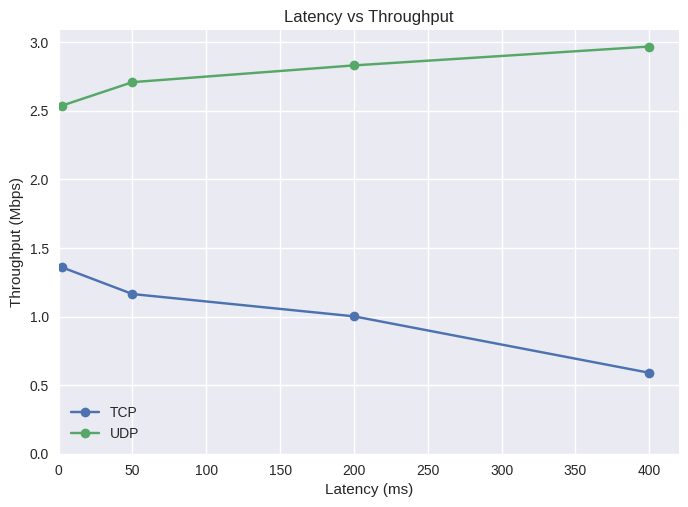

In [ ]:
create_graph("Latency", "ThroughputMbps", df_latency, "Latency vs Throughput", "Latency (ms)", "Throughput (Mbps)")

In [ ]:
packet_loss_latency_df = df_latency[["Latency", "Protocol", "LostPackets"]]
packet_loss_latency_df.rename(columns={'Latency': 'Latency (ms)'})

,Latency (ms),Protocol,LostPackets
0,2,TCP,70
1,2,UDP,3303
2,50,TCP,59
3,50,UDP,2063
4,200,TCP,0
5,200,UDP,1063
6,400,TCP,0
7,400,UDP,0


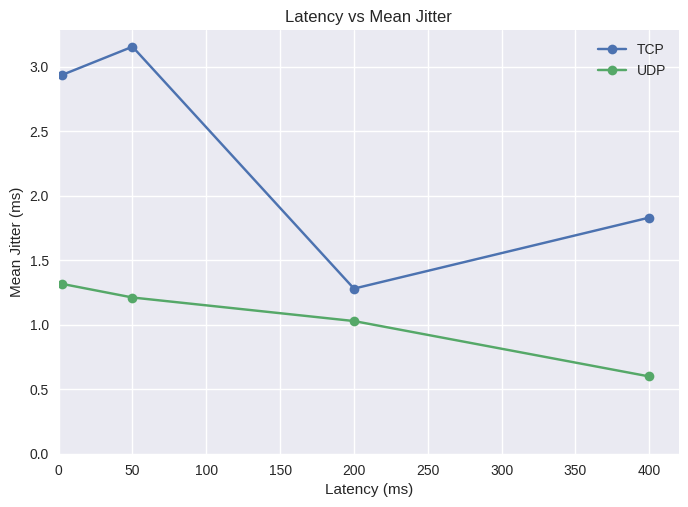

In [ ]:
create_graph("Latency", "MeanJitterMs", df_latency, "Latency vs Mean Jitter", "Latency (ms)", "Mean Jitter (ms)")

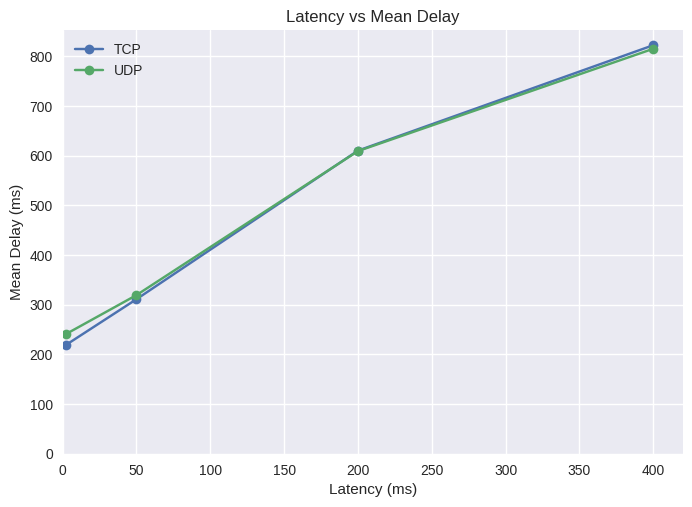

In [ ]:
create_graph("Latency", "MeanDelayMs", df_latency, "Latency vs Mean Delay", "Latency (ms)", "Mean Delay (ms)")

In [ ]:
fairness_latency = 4*[0]
for i in range(4):
  x1 = df_latency.iloc[2*i]['ThroughputKbps']
  x2 = df_latency.iloc[2*i+1]['ThroughputKbps']
  fairness_latency[i] = (x1 + x2)**2 / (2*(x1**2 + x2**2))

fairness_latency_df = pd.DataFrame({"Latency (ms)": df_latency['Latency'].unique(),"Fairness": fairness_latency})
fairness_latency_df

,Latency (ms),Fairness
0,2,0.916416
1,50,0.862751
2,200,0.814452
3,400,0.691196


## Low Latency Congestion Graphs

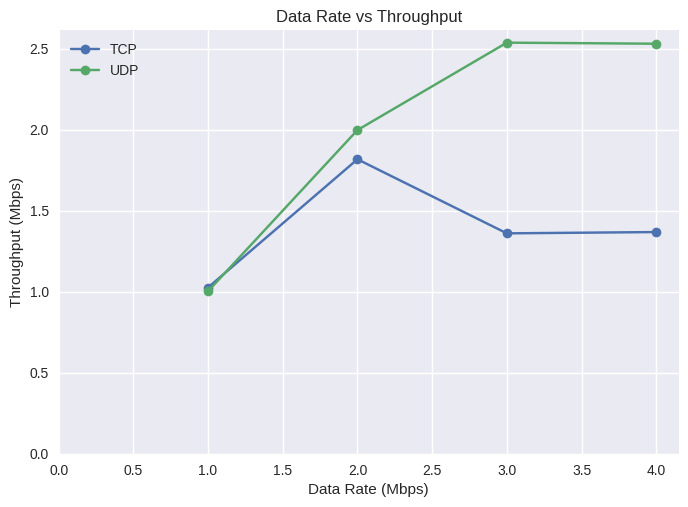

In [ ]:
create_graph("Mbps", "ThroughputMbps", df_low_latency_congestion, "Data Rate vs Throughput", "Data Rate (Mbps)", "Throughput (Mbps)")

In [ ]:
packet_loss_low_latency_congestion_df = df_low_latency_congestion[["Mbps", "Protocol", "LostPackets"]].rename(columns={'Mbps': 'Data Rate (Mbps)'})
packet_loss_low_latency_congestion_df

,Data Rate (Mbps),Protocol,LostPackets
0,1,TCP,0
1,1,UDP,0
2,2,TCP,76
3,2,UDP,23
4,3,TCP,70
5,3,UDP,3303
6,4,TCP,34
7,4,UDP,10461


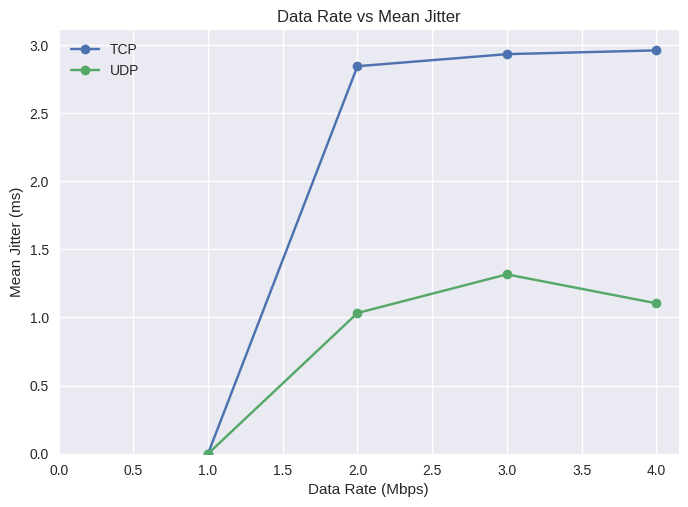

In [ ]:
create_graph("Mbps", "MeanJitterMs", df_low_latency_congestion, "Data Rate vs Mean Jitter", "Data Rate (Mbps)", "Mean Jitter (ms)")

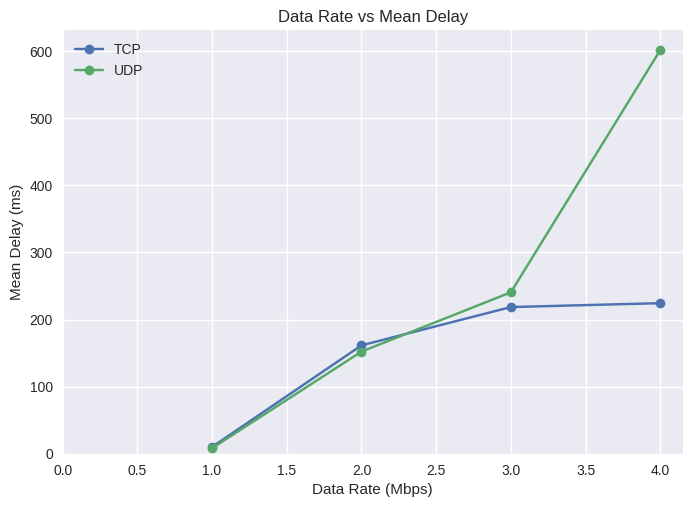

In [ ]:
create_graph("Mbps", "MeanDelayMs", df_low_latency_congestion, "Data Rate vs Mean Delay", "Data Rate (Mbps)", "Mean Delay (ms)")

In [ ]:
fairness_low_latency_congestion = 4*[0]
for i in range(4):
  x1 = df_low_latency_congestion.iloc[2*i]['ThroughputKbps']
  x2 = df_low_latency_congestion.iloc[2*i+1]['ThroughputKbps']
  fairness_low_latency_congestion[i] = (x1 + x2)**2 / (2*(x1**2 + x2**2))

fairness_low_latency_congestion_df = pd.DataFrame({"Data Rate(Mbps)": df_low_latency_congestion['Mbps'].unique(),"Fairness": fairness_low_latency_congestion})
fairness_low_latency_congestion_df


,Data Rate(Mbps),Fairness
0,1,0.999876
1,2,0.997768
2,3,0.916416
3,4,0.918357


## High Latency Congestion Graphs

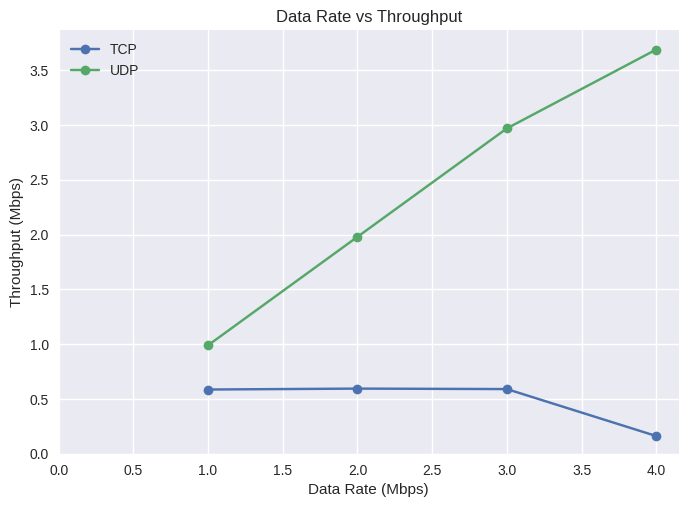

In [ ]:
create_graph("Mbps", "ThroughputMbps", df_high_latency_congestion, "Data Rate vs Throughput", "Data Rate (Mbps)", "Throughput (Mbps)")

In [ ]:
packet_loss_high_latency_congestion_df = df_high_latency_congestion[["Mbps", "Protocol", "LostPackets"]].rename(columns={'Mbps': 'Data Rate (Mbps)'})
packet_loss_high_latency_congestion_df

,Data Rate (Mbps),Protocol,LostPackets
0,1,TCP,0
1,1,UDP,0
2,2,TCP,0
3,2,UDP,0
4,3,TCP,0
5,3,UDP,0
6,4,TCP,18
7,4,UDP,1777


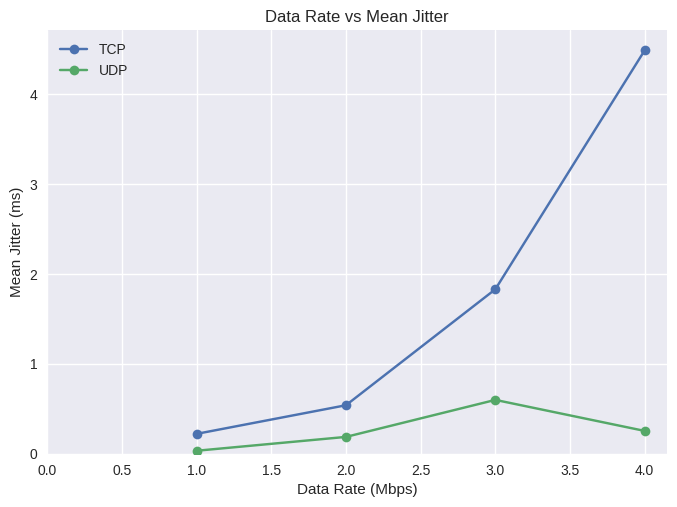

In [ ]:
create_graph("Mbps", "MeanJitterMs", df_high_latency_congestion, "Data Rate vs Mean Jitter", "Data Rate (Mbps)", "Mean Jitter (ms)")

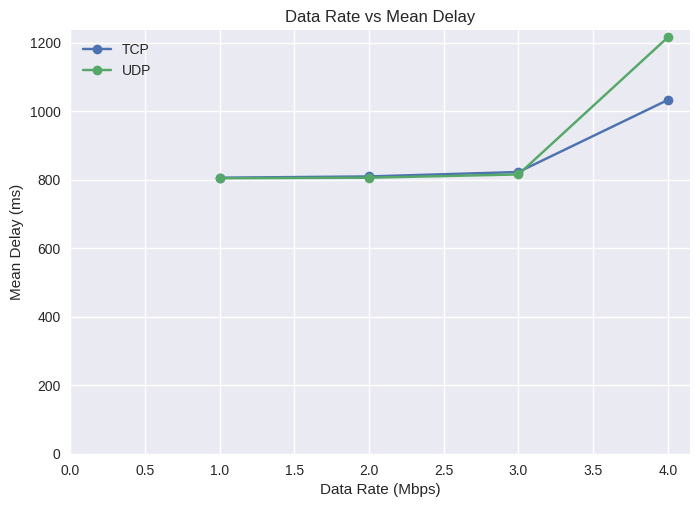

In [ ]:
create_graph("Mbps", "MeanDelayMs", df_high_latency_congestion, "Data Rate vs Mean Delay", "Data Rate (Mbps)", "Mean Delay (ms)")

In [ ]:
fairness_high_latency_congestion = 4*[0]
for i in range(4):
  x1 = df_high_latency_congestion.iloc[2*i]['ThroughputKbps']
  x2 = df_high_latency_congestion.iloc[2*i+1]['ThroughputKbps']
  fairness_high_latency_congestion[i] = (x1 + x2)**2 / (2*(x1**2 + x2**2))

fairness_high_latency_congestion_df = pd.DataFrame({"Data Rate (Mbps)": df_high_latency_congestion['Mbps'].unique(),"Fairness": fairness_high_latency_congestion})
fairness_high_latency_congestion_df

,Data Rate (Mbps),Fairness
0,1,0.938374
1,2,0.775426
2,3,0.691196
3,4,0.543696
